# Global Weather Trend Forecasting

## Objective

This project analyzes daily weather observations from capital cities around
the world and develops forecasting models for future temperature trends.

## Dataset

The Global Weather Repository contains daily weather and air-quality
information for capital cities worldwide, beginning on May 16, 2024.

## PM Accelerator Mission

PM Accelerator is committed to breaking down financial barriers and
promoting educational fairness. Through its educational initiatives,
including PMA Kids, it aims to empower underserved students, improve
career opportunities, and foster greater diversity in the technology
industry.

## Notebook Structure

1. Imports and setup  
2. Initial data inspection  
3. Location coverage and filtering  
4. Weather and air-quality validity checks  
5. Final feature creation and export

---

## 1. Imports and Setup

In [12]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42


## 2. Data Cleaning and Preprocessing

In [13]:
df_raw = pd.read_csv("GlobalWeatherRepository.csv")
print(df_raw.shape)

(153971, 41)


In [14]:
df_raw.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [15]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 153971 entries, 0 to 153970
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       153971 non-null  str    
 1   location_name                 153971 non-null  str    
 2   latitude                      153971 non-null  float64
 3   longitude                     153971 non-null  float64
 4   timezone                      153971 non-null  str    
 5   last_updated_epoch            153971 non-null  int64  
 6   last_updated                  153971 non-null  str    
 7   temperature_celsius           153971 non-null  float64
 8   temperature_fahrenheit        153971 non-null  float64
 9   condition_text                153971 non-null  str    
 10  wind_mph                      153971 non-null  float64
 11  wind_kph                      153971 non-null  float64
 12  wind_degree                   153971 non-null  int64  


In [16]:
print(df_raw.columns.tolist())

['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [17]:
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"Countries: {df_raw['country'].nunique()}")
print(f"Locations: {df_raw['location_name'].nunique()}")

Rows: 153,971
Columns: 41
Countries: 211
Locations: 268


### 2.1 Check Missing Values

In [18]:
missing_summary = (
    df_raw.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary.head(20)

,missing_count
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


### 2.2 Check Duplicates

In [19]:
print("Exact duplicate rows:", df_raw.duplicated().sum())

Exact duplicate rows: 0


In [20]:
duplicate_keys = df_raw.duplicated(
    subset=["country", "location_name", "last_updated"],
    keep=False
)

print("Duplicate location-time records:", duplicate_keys.sum())

Duplicate location-time records: 2


### 2.3 Check Date Coverage

In [21]:
df_raw["last_updated"] = pd.to_datetime(
    df_raw["last_updated"],
    errors="coerce"
)

print("Earliest date:", df_raw["last_updated"].min())
print("Latest date:", df_raw["last_updated"].max())
print("Invalid dates:", df_raw["last_updated"].isna().sum())

Earliest date: 2024-05-16 01:45:00
Latest date: 2026-07-18 19:00:00
Invalid dates: 0


### 2.4 Check Observations per City

In [22]:
city_counts = (
    df_raw.groupby(["country", "location_name"])
    .size()
    .reset_index(name="observations")
    .sort_values("observations", ascending=False)
)

city_counts

,country,location_name,observations
36,Burundi,Bujumbura,792
260,Ukraine,Kyiv,792
278,Yemen,Sanaa,792
49,Chad,N'djamena,792
86,Ghana,Accra,792
...,...,...,...
281,Гватемала,New Guatemala,1
282,Польша,Beirut,1
283,Турция,Yaren,1
284,كولومبيا,Costa Rica,1


### 2.5 Remove Redundant Features

Several features represent the same measurement in different units:

- Celsius and Fahrenheit
- km/h and mph
- millimetres and inches
- kilometres and miles
- millibars and inches
- gust km/h and gust mph
- timestamp and epoch timestamp

Keeping both versions can create multicollinearity and artificially inflate feature importance.

In [23]:
redundant_columns = [
    "temperature_fahrenheit",
    "wind_mph",
    "pressure_in",
    "precip_in",
    "feels_like_fahrenheit",
    "visibility_miles",
    "gust_mph",
    "last_updated_epoch"
]

df = df_raw.drop(
    columns=[col for col in redundant_columns if col in df_raw.columns]
).copy()

df.shape

(153971, 33)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153971 entries, 0 to 153970
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       153971 non-null  str           
 1   location_name                 153971 non-null  str           
 2   latitude                      153971 non-null  float64       
 3   longitude                     153971 non-null  float64       
 4   timezone                      153971 non-null  str           
 5   last_updated                  153971 non-null  datetime64[us]
 6   temperature_celsius           153971 non-null  float64       
 7   condition_text                153971 non-null  str           
 8   wind_kph                      153971 non-null  float64       
 9   wind_degree                   153971 non-null  int64         
 10  wind_direction                153971 non-null  str           
 11  pressure_mb             

In [25]:
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153966,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,2026-07-18 01:45:00,17.9,Mist,6.1,155,SSE,1017.0,0.0,97,56,12.7,2.0,0.0,12.9,549.0,24.0,5.3,1.7,1.7,2.6,1,1,06:14 AM,06:53 PM,10:03 AM,10:26 PM,Waxing Crescent,18
153967,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,2026-07-18 12:45:00,35.1,Cloudy,9.0,251,WSW,1001.0,0.0,56,25,45.3,10.0,11.7,10.4,403.0,190.0,5.0,16.0,27.3,31.8,2,3,05:25 AM,06:40 PM,09:01 AM,09:36 PM,Waxing Crescent,14
153968,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,2026-07-18 08:45:00,22.8,Sunny,6.1,352,N,1013.0,0.0,30,17,17.6,10.0,2.4,7.1,108.0,90.0,1.5,3.1,28.8,91.0,2,3,05:41 AM,06:37 PM,09:20 AM,09:49 PM,Waxing Crescent,16
153969,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,2026-07-18 07:45:00,12.7,Cloudy,7.9,86,E,1023.0,0.0,54,78,8.8,10.0,0.2,16.0,211.0,66.0,2.1,2.7,13.4,14.8,1,2,06:33 AM,05:52 PM,09:35 AM,09:53 PM,Waxing Crescent,16


In [26]:
redundant_pairs = [
    ("temperature_celsius", "temperature_fahrenheit"),
    ("wind_kph", "wind_mph"),
    ("precip_mm", "precip_in"),
    ("visibility_km", "visibility_miles"),
    ("gust_kph", "gust_mph")
]

for metric_col, imperial_col in redundant_pairs:
    if metric_col in df_raw.columns and imperial_col in df_raw.columns:
        corr = df_raw[[metric_col, imperial_col]].corr().iloc[0, 1]
        print(f"{metric_col} vs {imperial_col}: {corr:.6f}")

temperature_celsius vs temperature_fahrenheit: 0.999997
wind_kph vs wind_mph: 0.999987
precip_mm vs precip_in: 0.997937
visibility_km vs visibility_miles: 0.992522
gust_kph vs gust_mph: 0.999992


Imperial-unit features were removed because they contained nearly identical information to their metric equivalents. Removing them reduced dimensionality and avoided artificial multicollinearity

The visibility correlation is slightly lower because values may have been rounded during unit conversion

## 3. Location Coverage and Filtering

The analyzed dataset contains 153,971 observations across 211 countries and 268 locations. Although the repository description indicates earlier coverage, the downloaded dataset used in this project covers May 16, 2024 through July 18, 2026

This step identifies how much historical data is available for each country-location pair. Locations with very few observations may not provide enough information for meaningful trend analysis and may represent inconsistent or temporary records.

In [27]:
city_counts = (
    df.groupby(["country", "location_name"])
      .size()
      .reset_index(name="observations")
      .sort_values("observations")
      .reset_index(drop=True)
)

display(city_counts.head(30))
display(city_counts["observations"].describe())

,country,location_name,observations
0,火鸡,-Kingdom,1
1,كولومبيا,Costa Rica,1
2,Турция,Yaren,1
3,Польша,Beirut,1
4,Гватемала,New Guatemala,1
5,USA United States of America,Palau,1
6,Turkménistan,Krasnyy Turkmenistan,1
7,USA United States of America,Grenada,1
8,USA United States of America,Moroni,1
9,Saint-Vincent-et-les-Grenadines,Kingstown,1


count    286.000000
mean     538.360140
std      348.899804
min        1.000000
25%       36.000000
50%      788.000000
75%      790.000000
max      792.000000
Name: observations, dtype: float64

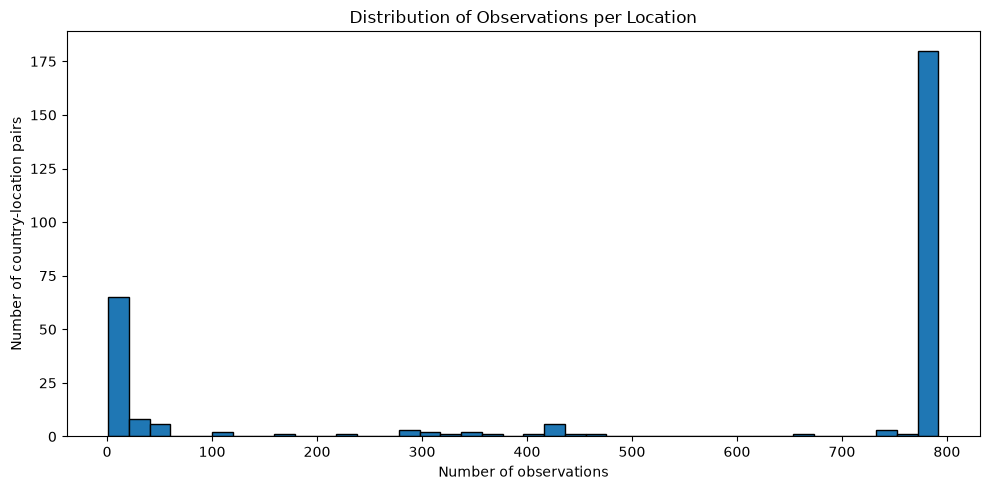

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(
    city_counts["observations"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Number of observations")
plt.ylabel("Number of country-location pairs")
plt.title("Distribution of Observations per Location")
plt.tight_layout()
plt.show()

In [29]:
thresholds = [1, 7, 30, 100, 365, 700]

for threshold in thresholds:
    count = (city_counts["observations"] < threshold).sum()
    print(f"Locations with fewer than {threshold} observations: {count}")

Locations with fewer than 1 observations: 0
Locations with fewer than 7 observations: 47
Locations with fewer than 30 observations: 67
Locations with fewer than 100 observations: 79
Locations with fewer than 365 observations: 91
Locations with fewer than 700 observations: 102


In [30]:
low_frequency_locations = city_counts.query("observations < 30")

display(low_frequency_locations)

,country,location_name,observations
0,火鸡,-Kingdom,1
1,كولومبيا,Costa Rica,1
2,Турция,Yaren,1
3,Польша,Beirut,1
4,Гватемала,New Guatemala,1
...,...,...,...
62,Jamaica,Bournemouth Gardens,18
63,Cameroon,Bafoussam,18
64,Palau,Adkip,20
65,Paraguay,Pasto,25


In [31]:
low_frequency_records = df.merge(
    low_frequency_locations[["country", "location_name"]],
    on=["country", "location_name"],
    how="inner"
)

display(
    low_frequency_records[
        [
            "country",
            "location_name",
            "last_updated",
            "latitude",
            "longitude",
            "temperature_celsius"
        ]
    ].sort_values(["country", "location_name", "last_updated"])
)

,country,location_name,last_updated,latitude,longitude,temperature_celsius
202,Australia,Melbourne,2024-06-25 23:15:00,-37.8200,144.9700,11.6
269,Australia,Melbourne,2026-06-04 16:15:00,-37.8167,144.9667,12.2
121,Belgium,'S Gravenjansdyk,2024-06-02 16:00:00,51.2500,3.6300,14.0
125,Belgium,'S Gravenjansdyk,2024-06-03 16:15:00,51.2500,3.6300,17.0
134,Belgium,'S Gravenjansdyk,2024-06-06 16:00:00,51.2500,3.6300,15.0
...,...,...,...,...,...,...
220,Гватемала,New Guatemala,2024-07-13 07:00:00,14.6200,-90.5300,15.9
224,Польша,Beirut,2024-07-13 15:00:00,51.1200,17.5300,24.2
228,Турция,Yaren,2024-07-13 16:00:00,39.5500,27.6200,34.0
218,كولومبيا,Costa Rica,2024-07-13 08:00:00,6.4300,-70.9200,23.1


Manual inspection showed that some low-frequency groups contained inconsistent or unusual location names, while others were valid locations with too little temporal coverage. Instead of manually correcting uncertain records, all locations below the chosen threshold were consistently excluded.

In [32]:
minimum_observations = 30

valid_locations = city_counts[
    city_counts["observations"] >= minimum_observations
][
    ["country", "location_name"]
]

df_clean = df.merge(
    valid_locations,
    on=["country", "location_name"],
    how="inner"
).copy()

In [33]:
rows_removed = len(df) - len(df_clean)

original_locations = (
    df[["country", "location_name"]]
    .drop_duplicates()
    .shape[0]
)

remaining_locations = (
    df_clean[["country", "location_name"]]
    .drop_duplicates()
    .shape[0]
)

print("Original raw dataset shape:", df_raw.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Rows removed:", rows_removed)
print("Original country-location pairs:", original_locations)
print("Remaining country-location pairs:", remaining_locations)

print(
    "Percentage of rows removed:",
    round(rows_removed / len(df) * 100, 3),
    "%"
)

Original raw dataset shape: (153971, 41)
Cleaned dataset shape: (153586, 33)
Rows removed: 385
Original country-location pairs: 286
Remaining country-location pairs: 219
Percentage of rows removed: 0.25 %


### 3.1 Removing Low-Frequency Locations

The number of observations was calculated for each country-location pair.
Several locations contained very limited historical coverage, and inspection
showed that some also had inconsistent or non-standard location names.

Country-location pairs with fewer than 30 observations were removed because
they did not provide enough data for meaningful temporal analysis. A single
threshold was applied consistently rather than manually correcting uncertain
records. This improved the consistency of the dataset while retaining
locations with adequate observation history.

The 30-observation threshold was used for the exploratory analysis dataset.
A stricter historical-coverage requirement will be applied later when
selecting locations for forecasting.

In [34]:
remaining_counts = (
    df_clean.groupby(["country", "location_name"])
            .size()
            .reset_index(name="observations")
            .sort_values("observations")
            .reset_index(drop=True)
)

print(
    "Minimum observations per remaining location:",
    remaining_counts["observations"].min()
)

display(remaining_counts.head(20))

Minimum observations per remaining location: 30


,country,location_name,observations
0,Cameroon,Aba,30
1,Palau,Aakip,32
2,Maldives,Felidhoo,34
3,Iceland,Grindavik,36
4,Paraguay,Sartorio,36
5,Jamaica,Norman Gardens,36
6,Russia,Chi-Chi-Erh,41
7,Vietnam,S. Manian,42
8,Iceland,Abaer,44
9,Costa Rica,San Andres,44


In [35]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 153586 entries, 0 to 153585
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       153586 non-null  str           
 1   location_name                 153586 non-null  str           
 2   latitude                      153586 non-null  float64       
 3   longitude                     153586 non-null  float64       
 4   timezone                      153586 non-null  str           
 5   last_updated                  153586 non-null  datetime64[us]
 6   temperature_celsius           153586 non-null  float64       
 7   condition_text                153586 non-null  str           
 8   wind_kph                      153586 non-null  float64       
 9   wind_degree                   153586 non-null  int64         
 10  wind_direction                153586 non-null  str           
 11  pressure_mb             

In [36]:
df_clean.describe()

,latitude,longitude,last_updated,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,153586.000000,153586.000000,153586,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000,153586.000000
mean,19.253656,21.891733,2025-06-17 07:31:23.210709,21.360945,12.780457,169.586460,1014.060982,0.131328,66.962230,39.460914,22.138564,9.514063,3.186774,18.090099,433.845715,57.778169,14.405850,9.873024,23.334906,46.859154,1.668323,2.534079,49.852968
min,-41.300000,-175.200000,2024-05-16 02:45:00,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,-36.700000,0.000000,0.000000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,2024-12-02 06:07:30,16.100000,6.100000,81.000000,1010.000000,0.000000,52.000000,0.000000,15.900000,10.000000,0.000000,10.000000,185.300000,38.000000,1.750000,1.110000,6.900000,9.700000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,2025-06-17 10:30:00,23.700000,10.800000,163.000000,1014.000000,0.000000,72.000000,26.000000,25.000000,10.000000,1.600000,15.100000,277.500000,55.000000,5.550000,2.405000,13.550000,19.240000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,2025-12-31 08:00:00,27.900000,17.600000,256.000000,1018.000000,0.020000,86.000000,75.000000,29.800000,10.000000,6.000000,24.000000,436.850000,73.000000,16.465000,7.770000,26.640000,40.100000,2.000000,3.000000,85.000000
max,65.300000,179.220000,2026-07-18 19:00:00,79.300000,2963.200000,360.000000,3006.000000,42.240000,100.000000,100.000000,81.300000,32.000000,16.300000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000
std,24.398265,65.734574,NaN,9.485152,11.254491,103.499565,9.952147,0.557375,23.634229,34.084836,11.379519,2.682289,3.510520,13.511829,722.994061,30.739171,22.817236,33.791241,35.450786,144.149459,0.924683,2.395531,35.129409


## 4. Weather and Air-Quality Validity Checks

It can be seen that some values are incorrect for example max temperature in celsius cannot be 79.3 or max pressure cannot be 3006 or wind 2963kph. Min air quality cannot be -9999. Thats why some data quality checks need to be done

In [37]:
temp_df = df_clean.copy()
print("shape: ",df_clean.shape)

shape:  (153586, 33)


In [38]:
weather_numeric_cols = [
    "temperature_celsius",
    "feels_like_celsius",
    "wind_kph",
    "gust_kph",
    "wind_degree",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "cloud",
    "visibility_km",
    "uv_index",
    "moon_illumination"
]

air_quality_cols = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

### 4.1 Check for Placeholder Values

Values such as -9999 are not realistic pollution concentrations. They are typically used to represent missing or unavailable measurements.

In [39]:
placeholder_values = [-9999, -999, -99]

placeholder_summary = {}

for column in air_quality_cols:
    placeholder_summary[column] = (
        temp_df[column].isin(placeholder_values).sum()
    )

placeholder_summary

{'air_quality_Carbon_Monoxide': np.int64(1),
 'air_quality_Ozone': np.int64(0),
 'air_quality_Nitrogen_dioxide': np.int64(0),
 'air_quality_Sulphur_dioxide': np.int64(1),
 'air_quality_PM2.5': np.int64(0),
 'air_quality_PM10': np.int64(0)}

In [40]:
placeholder_summary_df = (
    pd.Series(placeholder_summary, name="placeholder_count")
      .to_frame()
      .sort_values("placeholder_count", ascending=False)
)

display(placeholder_summary_df)

,placeholder_count
air_quality_Carbon_Monoxide,1
air_quality_Sulphur_dioxide,1
air_quality_Ozone,0
air_quality_Nitrogen_dioxide,0
air_quality_PM2.5,0
air_quality_PM10,0


#### Replace Placeholder Values with `NaN`

In [41]:

temp_df[air_quality_cols] = temp_df[air_quality_cols].replace(
    placeholder_values,
    np.nan
)

In [42]:
for value in placeholder_values:
    count = temp_df[air_quality_cols].eq(value).sum().sum()
    print(f"Remaining occurrences of {value}: {count}")

Remaining occurrences of -9999: 0
Remaining occurrences of -999: 0
Remaining occurrences of -99: 0


### 4.2 Check Negative Air-Quality Measurements

Air-pollution concentrations should not be negative. Negative readings can happen because of instrument background noise, natural sensor drift, and small measurement errors.

In [43]:
negative_air_quality_counts = (
    temp_df[air_quality_cols]
    .lt(0)
    .sum()
    .sort_values(ascending=False)
)

display(
    negative_air_quality_counts.to_frame(
        name="negative_values"
    )
)

,negative_values
air_quality_PM10,2
air_quality_Carbon_Monoxide,0
air_quality_Ozone,0
air_quality_Nitrogen_dioxide,0
air_quality_Sulphur_dioxide,0
air_quality_PM2.5,0


In [44]:
negative_air_quality_mask = (
    temp_df[air_quality_cols] < 0
).any(axis=1)

negative_air_quality_rows = temp_df.loc[
    negative_air_quality_mask,
    [
        "country",
        "location_name",
        "last_updated",
        *air_quality_cols
    ]
]

display(negative_air_quality_rows.head(30))

,country,location_name,last_updated,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
55065,Saudi Arabia,Riyadh,2025-02-25 13:00:00,432.90,81.0,23.68,28.675,639.175,-1848.15
119955,Saudi Arabia,Riyadh,2026-01-25 10:00:00,181.85,56.0,14.65,23.050,443.250,-998.15


#### Replace Negative Air-Quality Values with `NaN`

In [45]:
temp_df[air_quality_cols] = temp_df[air_quality_cols].mask(
    temp_df[air_quality_cols] < 0,
    np.nan
)

In [46]:
print(
    "Remaining negative air-quality values:",
    temp_df[air_quality_cols].lt(0).sum().sum()
)

Remaining negative air-quality values: 0


### 4.3 Define Conservative Validity Ranges

In [47]:
valid_ranges = {
    "temperature_celsius": (-60, 60),
    "feels_like_celsius": (-80, 70),
    "wind_kph": (0, 450),
    "gust_kph": (0, 500),
    "wind_degree": (0, 360),
    "pressure_mb": (850, 1100),
    "precip_mm": (0, 500),
    "humidity": (0, 100),
    "cloud": (0, 100),
    "visibility_km": (0, 100),
    "uv_index": (0, 25),
    "moon_illumination": (0, 100),
    "latitude": (-90, 90),
    "longitude": (-180, 180)
}

#### Count Invalid Values in Each Column

In [48]:
quality_summary = []

for column, (lower, upper) in valid_ranges.items():
    below_range = (df[column] < lower).sum()
    above_range = (df[column] > upper).sum()
    total_invalid = below_range + above_range

    quality_summary.append({
        "column": column,
        "minimum_allowed": lower,
        "maximum_allowed": upper,
        "below_range": below_range,
        "above_range": above_range,
        "total_invalid": total_invalid
    })

quality_summary_df = pd.DataFrame(quality_summary)

display(
    quality_summary_df.sort_values(
        "total_invalid",
        ascending=False
    )
)

,column,minimum_allowed,maximum_allowed,below_range,above_range,total_invalid
5,pressure_mb,850,1100,0,2,2
0,temperature_celsius,-60,60,0,1,1
1,feels_like_celsius,-80,70,0,1,1
2,wind_kph,0,450,0,1,1
3,gust_kph,0,500,0,1,1
4,wind_degree,0,360,0,0,0
6,precip_mm,0,500,0,0,0
7,humidity,0,100,0,0,0
8,cloud,0,100,0,0,0
9,visibility_km,0,100,0,0,0


### 4.4 Inspect Suspicious Temperature Records

In [49]:
temperature_mask = ~temp_df["temperature_celsius"].between(
    valid_ranges["temperature_celsius"][0],
    valid_ranges["temperature_celsius"][1]
)

suspicious_temperatures = temp_df.loc[
    temperature_mask,
    [
        "country",
        "location_name",
        "last_updated",
        "temperature_celsius",
        "feels_like_celsius",
        "humidity",
        "condition_text",
        "latitude",
        "longitude"
    ]
].sort_values(
    "temperature_celsius",
    ascending=False
)

display(suspicious_temperatures)

,country,location_name,last_updated,temperature_celsius,feels_like_celsius,humidity,condition_text,latitude,longitude
137025,Fiji Islands,Suva,2026-04-24 18:30:00,79.3,81.3,7,Partly cloudy,-18.1333,178.4167


Temperature and feels-like temperature should usually be related. A very large difference may indicate an error.

In [50]:
temp_df["temp_feels_difference"] = (
    temp_df["feels_like_celsius"]
    - temp_df["temperature_celsius"]
).abs()

display(
    temp_df[
        [
            "country",
            "location_name",
            "last_updated",
            "temperature_celsius",
            "feels_like_celsius",
            "temp_feels_difference"
        ]
    ]
    .sort_values("temp_feels_difference", ascending=False)
    .head(20)
)

,country,location_name,last_updated,temperature_celsius,feels_like_celsius,temp_feels_difference
3278,Jamaica,Norman Gardens,2024-06-01 09:30:00,32.0,49.9,17.9
75469,Malaysia,Kuala Lumpur,2025-06-10 17:00:00,32.3,49.9,17.6
20012,Thailand,Nan,2024-08-29 19:00:00,32.2,49.6,17.4
80530,Thailand,Nan,2025-07-06 16:30:00,32.0,49.4,17.4
1530,Cambodia,Phnom Penh,2024-05-23 21:00:00,32.0,49.3,17.3
10366,Thailand,Nan,2024-07-08 20:00:00,32.3,49.5,17.2
102484,Brunei Darussalam,Bandar Seri Begawan,2025-10-27 16:15:00,32.2,49.3,17.1
7293,Thailand,Nan,2024-06-22 20:45:00,32.4,49.2,16.8
21187,Malaysia,Kuala Lumpur,2024-09-04 20:00:00,33.0,49.8,16.8
76242,Thailand,Nan,2025-06-14 16:00:00,33.3,50.0,16.7


### 4.5 Inspect Suspicious Wind and Gust Values

In [51]:
wind_mask = ~temp_df["wind_kph"].between(
    *valid_ranges["wind_kph"]
)

gust_mask = ~temp_df["gust_kph"].between(
    *valid_ranges["gust_kph"]
)

suspicious_wind = temp_df.loc[
    wind_mask | gust_mask,
    [
        "country",
        "location_name",
        "last_updated",
        "wind_kph",
        "gust_kph",
        "wind_degree",
        "condition_text"
    ]
].sort_values(
    "wind_kph",
    ascending=False
)

display(suspicious_wind)

,country,location_name,last_updated,wind_kph,gust_kph,wind_degree,condition_text
7417,Burundi,Bujumbura,2024-06-23 15:45:00,2963.2,2970.4,180,Partly cloudy


In [52]:
display(
    temp_df[
        [
            "country",
            "location_name",
            "last_updated",
            "wind_kph",
            "gust_kph"
        ]
    ]
    .sort_values("wind_kph", ascending=False)
    .head(20)
)

,country,location_name,last_updated,wind_kph,gust_kph
7417,Burundi,Bujumbura,2024-06-23 15:45:00,2963.2,2970.4
7065,Ethiopia,Addis Ababa,2024-06-21 16:30:00,272.2,279.4
1151,Burundi,Bujumbura,2024-05-21 16:45:00,258.8,266.0
8468,Saint Kitts and Nevis,Basseterre,2024-06-28 09:15:00,205.9,213.1
804,Fiji Islands,Suva,2024-05-20 02:00:00,172.1,179.3
51288,Iceland,Vestmannaeyjar,2025-02-06 10:15:00,91.1,119.9
8920,Barbados,Bridgetown,2024-07-01 09:15:00,81.0,85.6
19654,Norway,Oslo,2024-08-27 14:15:00,78.1,85.3
35142,Iceland,Vestmannaeyjar,2024-11-15 09:00:00,76.7,99.1
42942,Iceland,Vestmannaeyjar,2024-12-25 10:15:00,76.0,105.4


### 4.6 Inspect Suspicious Pressure Values

In [53]:
pressure_mask = ~temp_df["pressure_mb"].between(
    *valid_ranges["pressure_mb"]
)

suspicious_pressure = temp_df.loc[
    pressure_mask,
    [
        "country",
        "location_name",
        "last_updated",
        "pressure_mb",
        "temperature_celsius",
        "wind_kph",
        "condition_text"
    ]
].sort_values(
    "pressure_mb",
    ascending=False
)

display(suspicious_pressure)

,country,location_name,last_updated,pressure_mb,temperature_celsius,wind_kph,condition_text
49531,Honduras,Tegucigalpa,2025-01-28 05:00:00,3006.0,19.1,10.4,Partly cloudy
51876,Iran,Tehran,2025-02-09 14:00:00,3000.0,2.1,8.3,Overcast


### 4.7 Check Whether Suspicious Values Occur Together

In [54]:
invalid_flags = pd.DataFrame(index=temp_df.index)

for column, (lower, upper) in valid_ranges.items():
    invalid_flags[f"invalid_{column}"] = (
        ~temp_df[column].between(lower, upper)
    )

temp_df["invalid_weather_value_count"] = invalid_flags.sum(axis=1)

In [55]:
display(
    temp_df.loc[
        temp_df["invalid_weather_value_count"] > 0,
        [
            "country",
            "location_name",
            "last_updated",
            "temperature_celsius",
            "feels_like_celsius",
            "wind_kph",
            "gust_kph",
            "pressure_mb",
            "precip_mm",
            "humidity",
            "invalid_weather_value_count"
        ]
    ]
    .sort_values(
        "invalid_weather_value_count",
        ascending=False
    )
    .head(30)
)

,country,location_name,last_updated,temperature_celsius,feels_like_celsius,wind_kph,gust_kph,pressure_mb,precip_mm,humidity,invalid_weather_value_count
7417,Burundi,Bujumbura,2024-06-23 15:45:00,22.5,24.6,2963.2,2970.4,1014.0,0.00,52,2
137025,Fiji Islands,Suva,2026-04-24 18:30:00,79.3,81.3,16.2,27.1,1013.0,0.99,7,2
49531,Honduras,Tegucigalpa,2025-01-28 05:00:00,19.1,19.1,10.4,18.3,3006.0,0.02,88,1
51876,Iran,Tehran,2025-02-09 14:00:00,2.1,-0.4,8.3,9.5,3000.0,0.02,60,1


In [56]:
print(
    "Rows containing at least one invalid weather value:",
    (temp_df["invalid_weather_value_count"] > 0).sum()
)

print(
    "Rows containing multiple invalid weather values:",
    (temp_df["invalid_weather_value_count"] > 1).sum()
)

Rows containing at least one invalid weather value: 4
Rows containing multiple invalid weather values: 2


### 4.8 Set Isolated Invalid Measurements to Missing

Replace each invalid field with `NaN` while preserving the rest of the row.

In [57]:
invalid_value_log = {}

for column, (lower, upper) in valid_ranges.items():
    invalid_mask = ~temp_df[column].between(lower, upper)

    invalid_value_log[column] = invalid_mask.sum()

    temp_df.loc[invalid_mask, column] = np.nan

In [58]:
invalid_value_log_df = (
    pd.Series(
        invalid_value_log,
        name="values_replaced_with_nan"
    )
    .to_frame()
    .sort_values(
        "values_replaced_with_nan",
        ascending=False
    )
)

display(invalid_value_log_df)

,values_replaced_with_nan
pressure_mb,2
temperature_celsius,1
feels_like_celsius,1
wind_kph,1
gust_kph,1
wind_degree,0
precip_mm,0
humidity,0
cloud,0
visibility_km,0


In [59]:
temp_df.drop(
    columns=[
        "invalid_weather_value_count",
        "temp_feels_difference"
    ],
    inplace=True,
    errors="ignore"
)

In [60]:
quality_missing_summary = (
    temp_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    quality_missing_summary.to_frame(
        name="missing_after_quality_checks"
    )
)

,missing_after_quality_checks
pressure_mb,2
air_quality_PM10,2
air_quality_Carbon_Monoxide,1
feels_like_celsius,1
wind_kph,1
gust_kph,1
air_quality_Sulphur_dioxide,1
temperature_celsius,1
country,0
condition_text,0


In [61]:
print("Shape before quality checks:", df_clean.shape)
print("Shape after quality checks:", temp_df.shape)

print("\nFinal numeric ranges:")

display(temp_df.describe())

Shape before quality checks: (153586, 33)
Shape after quality checks: (153586, 33)

Final numeric ranges:


,latitude,longitude,last_updated,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,153586.000000,153586.000000,153586,153585.000000,153585.000000,153586.000000,153584.000000,153586.000000,153586.000000,153586.000000,153585.000000,153586.000000,153586.000000,153585.000000,153585.000000,153586.000000,153586.000000,153585.000000,153586.000000,153584.000000,153586.000000,153586.000000,153586.000000
mean,19.253656,21.891733,2025-06-17 07:31:23.210709,21.360568,12.761247,169.586460,1014.035082,0.131328,66.962230,39.460914,22.138179,9.514063,3.186774,18.070877,433.913644,57.778169,14.405850,9.938192,23.334906,46.878297,1.668323,2.534079,49.852968
min,-41.300000,-175.200000,2024-05-16 02:45:00,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,-36.700000,0.000000,0.000000,3.600000,53.850000,0.000000,0.000000,0.000000,0.168000,0.168000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,2024-12-02 06:07:30,16.100000,6.100000,81.000000,1010.000000,0.000000,52.000000,0.000000,15.900000,10.000000,0.000000,10.000000,185.300000,38.000000,1.750000,1.110000,6.900000,9.700000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,2025-06-17 10:30:00,23.700000,10.800000,163.000000,1014.000000,0.000000,72.000000,26.000000,25.000000,10.000000,1.600000,15.100000,277.500000,55.000000,5.550000,2.405000,13.550000,19.240000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,2025-12-31 08:00:00,27.900000,17.600000,256.000000,1018.000000,0.020000,86.000000,75.000000,29.800000,10.000000,6.000000,24.000000,436.850000,73.000000,16.465000,7.770000,26.640000,40.100000,2.000000,3.000000,85.000000
max,65.300000,179.220000,2026-07-18 19:00:00,49.200000,272.200000,360.000000,1080.000000,42.240000,100.000000,100.000000,51.200000,32.000000,16.300000,279.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000
std,24.398265,65.734574,NaN,9.484030,8.365710,103.499565,6.894288,0.557375,23.634229,34.084836,11.378554,2.682289,3.510520,11.216896,722.506135,30.739171,22.817236,22.126583,35.450786,144.044592,0.924683,2.395531,35.129409


### 4.9 Weather Measurement Validity Checks

Descriptive statistics revealed several values outside plausible measurement
ranges, including extremely high temperature, wind speed, wind gust and
atmospheric pressure values. Some air-quality variables also contained
negative values such as -9999, which were interpreted as missing-value
placeholders rather than valid pollution measurements.

Broad validity ranges were defined for the weather variables to identify
likely data-entry, unit or measurement errors without removing genuine
extreme weather events. Invalid individual measurements were replaced with
missing values while preserving the remaining information in each record.
Rows containing multiple invalid measurements were inspected separately
because they were more likely to represent corrupted observations.

## 5. Final Dataset Preparation and Export

In [62]:
df = temp_df.copy()

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153586 entries, 0 to 153585
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       153586 non-null  str           
 1   location_name                 153586 non-null  str           
 2   latitude                      153586 non-null  float64       
 3   longitude                     153586 non-null  float64       
 4   timezone                      153586 non-null  str           
 5   last_updated                  153586 non-null  datetime64[us]
 6   temperature_celsius           153585 non-null  float64       
 7   condition_text                153586 non-null  str           
 8   wind_kph                      153585 non-null  float64       
 9   wind_degree                   153586 non-null  float64       
 10  wind_direction                153586 non-null  str           
 11  pressure_mb             

In [64]:
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["month_name"] = df["last_updated"].dt.month_name()
df["day_of_week"] = df["last_updated"].dt.day_name()
df["hour"] = df["last_updated"].dt.hour

In [65]:
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338.0,NNW,1012.0,0.0,24.0,30.0,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,13
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320.0,NW,1012.0,0.1,94.0,75.0,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280.0,W,1011.0,0.0,29.0,0.0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215.0,SW,1007.0,0.3,61.0,100.0,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150.0,SSE,1011.0,0.0,89.0,50.0,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153581,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,2026-07-18 01:45:00,17.9,Mist,6.1,155.0,SSE,1017.0,0.0,97.0,56.0,12.7,2.0,0.0,12.9,549.0,24.0,5.3,1.7,1.7,2.6,1,1,06:14 AM,06:53 PM,10:03 AM,10:26 PM,Waxing Crescent,18.0,2026,7,July,Saturday,1
153582,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,2026-07-18 12:45:00,35.1,Cloudy,9.0,251.0,WSW,1001.0,0.0,56.0,25.0,45.3,10.0,11.7,10.4,403.0,190.0,5.0,16.0,27.3,31.8,2,3,05:25 AM,06:40 PM,09:01 AM,09:36 PM,Waxing Crescent,14.0,2026,7,July,Saturday,12
153583,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,2026-07-18 08:45:00,22.8,Sunny,6.1,352.0,N,1013.0,0.0,30.0,17.0,17.6,10.0,2.4,7.1,108.0,90.0,1.5,3.1,28.8,91.0,2,3,05:41 AM,06:37 PM,09:20 AM,09:49 PM,Waxing Crescent,16.0,2026,7,July,Saturday,8
153584,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,2026-07-18 07:45:00,12.7,Cloudy,7.9,86.0,E,1023.0,0.0,54.0,78.0,8.8,10.0,0.2,16.0,211.0,66.0,2.1,2.7,13.4,14.8,1,2,06:33 AM,05:52 PM,09:35 AM,09:53 PM,Waxing Crescent,16.0,2026,7,July,Saturday,7


In [66]:
df.to_csv("weather_cleaned.csv", index=False)